# Statistical Validation of the Checkout Path Gap

The funnel analysis (see `sql/02_funnel_analysis.sql`) found that users who reach
checkout via the cart convert to purchase at 51.5%, against 37.1% for users who
go straight to checkout.

This notebook asks three separate questions about that gap:

1. **Could it be chance?** — two-proportion z-test
2. **How precisely do we know it?** — confidence intervals
3. **How large is it, independent of sample size?** — Cohen's h

Each alone is misleading. A p-value alone makes a trivial gap look impressive
given enough data. An effect size alone does not tell you whether the difference
is real. This is the same discipline applied in the Olist project, where a
Welch's t-test was reported alongside Cohen's d.

**Source of the numbers:** all counts are hardcoded from BigQuery query results
rather than pulled live. Connecting Python to BigQuery requires credential setup
that adds nothing for eight numbers, and hardcoding keeps the notebook
reproducible by anyone reading it. Each block comments

In [2]:
import statsmodels
print(statsmodels.__version__)

0.15.0


## The data

Base population: the 9,715 users who fired `begin_checkout`, split by whether
they had also fired `add_to_cart` at any point.

Note that `add_to_cart` is treated here as a **path attribute**, not a funnel
step. The original funnel treated it as a mandatory stage, but 1,504 purchasers
— 34% of all buyers — reached purchase without ever firing it, while every
single purchaser fired `begin_checkout`. That pattern indicates a second route
into checkout rather than lost tracking, and the funnel was rebuilt accordingly.

In [3]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# Results from BigQuery (02_funnel_analysis.sql, Query 5)
# Users who reached begin_checkout, split by whether they used the cart

cart_total = 5657
cart_purchased = 2915

direct_total = 4058
direct_purchased = 1504

cart_rate = cart_purchased / cart_total
direct_rate = direct_purchased / direct_total

print("Cart path conversion:", round(cart_rate * 100, 2), "%")
print("Direct path conversion:", round(direct_rate * 100, 2), "%")
print("Gap:", round((cart_rate - direct_rate) * 100, 2), "pp")

Cart path conversion: 51.53 %
Direct path conversion: 37.06 %
Gap: 14.47 pp


## Checking the test's assumption before running it

The two-proportion z-test relies on the normal approximation to the binomial
distribution, which requires at least 10 successes and 10 failures in each
group.

This cell exists so the check is visible in the notebook rather than assumed.
Verifying an assumption before using a test — and leaving the verification where
a reader can see it — is what separates a defensible analysis from a
plausible-looking one.

In [4]:
print("Cart path  - purchased:", cart_purchased, " did not:", cart_total - cart_purchased)
print("Direct path - purchased:", direct_purchased, " did not:", direct_total - direct_purchased)

Cart path  - purchased: 2915  did not: 2742
Direct path - purchased: 1504  did not: 2554


## Two-proportion z-test

**Why this test.** The outcome is binary — each user either purchased or did
not — so the quantity being compared is a proportion, not a mean. This is the
proportion analogue of the Welch's t-test used in the Olist project, where the
outcome (review score) was continuous.

**What it does.** Assume both paths convert at the same true rate. Calculate how
much two samples of 5,657 and 4,058 users would be expected to differ purely by
chance (the standard error). Express the observed gap in units of that expected
wobble (the z-statistic). Convert to the probability of seeing a gap at least
this extreme under that assumption (the p-value).

**What the p-value is not.** It is the probability of the data given the null
hypothesis, not the probability that the null is true. These are different
statements. The 0.05 threshold is a convention, not a law — p = 0.049 and
p = 0.051 are nearly identical evidence.

In [5]:
successes = np.array([cart_purchased, direct_purchased])
totals = np.array([cart_total, direct_total])

z_stat, p_value = proportions_ztest(count=successes, nobs=totals)

print("z-statistic:", round(z_stat, 3))
print("p-value:", p_value)

z-statistic: 14.122
p-value: 2.7781056533535774e-45


### Result

z = 14.12, p = 2.78e-45, reported as **p < 0.001**. Quoting 45 decimal places of
precision from an approximation would be misleading; the difference between
"very unlikely" and "astronomically unlikely" carries no additional meaning.

The observed gap is roughly fourteen standard errors wide. It is not an accident
of sampling.

**This says nothing about causation.** A z of 14 establishes that the two groups
genuinely differ, not what makes them differ.

## Confidence intervals

51.53% is one sample's estimate of the cart path's true conversion rate. A 95%
confidence interval gives the range of true values consistent with what was
observed: across many repetitions of this study, roughly 95% of the intervals
constructed this way would contain the true rate.

**Why the Wilson method.** The textbook normal-approximation formula misbehaves
for proportions near 0 or 1 and can produce intervals extending below 0% or
above 100%. Wilson does not. `statsmodels` offers several methods; choosing one
deliberately matters more than accepting a default.

In [6]:
cart_lower, cart_upper = proportion_confint(cart_purchased, cart_total, alpha=0.05, method='wilson')
direct_lower, direct_upper = proportion_confint(direct_purchased, direct_total, alpha=0.05, method='wilson')

print("Cart path:  ", round(cart_rate*100, 2), "% -- 95% CI [", round(cart_lower*100, 2), ",", round(cart_upper*100, 2), "]")
print("Direct path:", round(direct_rate*100, 2), "% -- 95% CI [", round(direct_lower*100, 2), ",", round(direct_upper*100, 2), "]")

Cart path:   51.53 % -- 95% CI [ 50.23 , 52.83 ]
Direct path: 37.06 % -- 95% CI [ 35.59 , 38.56 ]


## Confidence interval on the difference

The interval that matters for a stakeholder is on the **gap**, not on each rate
separately.

A common error: non-overlapping individual intervals do imply a significant
difference, but the converse does not hold — two intervals can overlap slightly
while the difference is still significant. The interval on the difference is the
correct one to quote.

The standard error of a difference between two proportions adds each group's
variance, `p(1-p)/n`, then takes the square root. The 1.96 multiplier is the
z-value bounding the middle 95% of a normal distribution.

In [7]:
import math

# Standard error of the difference between two proportions
se_diff = math.sqrt(
    (cart_rate * (1 - cart_rate)) / cart_total
    + (direct_rate * (1 - direct_rate)) / direct_total
)

diff = cart_rate - direct_rate
margin = 1.96 * se_diff

print("Gap:", round(diff*100, 2), "pp")
print("95% CI: [", round((diff - margin)*100, 2), ",", round((diff + margin)*100, 2), "]")

Gap: 14.47 pp
95% CI: [ 12.49 , 16.44 ]


## Effect size — Cohen's h

The p-value establishes the gap is real. It says nothing about whether it is
large. With enough data, a 0.01pp difference returns p < 0.001 — real and
useless. Effect size answers the separate question of magnitude, independent of
sample size.

**Why an arcsine transformation.** Raw percentage-point differences are not
equally meaningful across the range. 1% → 6% is a sixfold increase; 50% → 55% is
a 10% relative change. Both are "5pp." The arcsine transformation stabilises
this so the measure means the same thing wherever it sits on the scale.

Conventional benchmarks: 0.2 small, 0.5 medium, 0.8 large. These are rules of
thumb Cohen intended as a fallback when no domain knowledge is available.

In [8]:
from statsmodels.stats.proportion import proportion_effectsize

h = proportion_effectsize(cart_rate, direct_rate)

print("Cohen's h:", round(h, 3))

Cohen's h: 0.292


### Interpreting h = 0.292

Small-to-medium by convention, which may read as an anticlimax next to z = 14.
It is not a contradiction — the two numbers answer different questions. The
large z comes partly from the gap and partly from having ~10,000 users; Cohen's
h removes sample size from the picture.

In commercial terms the label understates it: 37.1% → 51.5% is a 39% relative
improvement in checkout conversion. Cohen's benchmarks were designed for use
without domain knowledge, and here there is some.

## Does the gap replicate across subgroups?

The pooled result could be driven by one unusual slice of the data. This applies
the same three measures to each time period and traffic channel separately.

Users are assigned to a period by their **first event**, so each user sits in
exactly one bucket. A per-event assignment would place the same user in two
periods and contaminate the comparison.

The `Smallest n` column is included deliberately — interval width depends on it,
and it should be visible next to the estimates rather than looked up separately.

In [9]:
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
import math

# Rows: label, cart total, cart purchased, direct total, direct purchased
subgroups = [
    ["Gift season", 4065, 2046, 3551, 1291],
    ["Trough",       938,  482,  301,  129],
    ["Recovery",     654,  387,  206,   84],
    ["Direct/(none)", 1391, 699,  904,  312],
    ["Organic",      2009, 1032, 1481,  525],
    ["Referral",      891,  468,  684,  276],
    ["CPC",           263,  140,  200,   78],
]

results = []

for row in subgroups:
    label = row[0]
    c_total = row[1]
    c_purch = row[2]
    d_total = row[3]
    d_purch = row[4]

    c_rate = c_purch / c_total
    d_rate = d_purch / d_total
    gap = c_rate - d_rate

    z, p = proportions_ztest(count=[c_purch, d_purch], nobs=[c_total, d_total])
    h = proportion_effectsize(c_rate, d_rate)

    se = math.sqrt((c_rate*(1-c_rate))/c_total + (d_rate*(1-d_rate))/d_total)
    lo = gap - 1.96*se
    hi = gap + 1.96*se

    results.append({
        "Segment": label,
        "Cart %": round(c_rate*100, 1),
        "Direct %": round(d_rate*100, 1),
        "Gap pp": round(gap*100, 2),
        "CI low": round(lo*100, 2),
        "CI high": round(hi*100, 2),
        "p": round(p, 5),
        "Cohen h": round(h, 3),
        "Smallest n": min(c_total, d_total),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      Segment  Cart %  Direct %  Gap pp  CI low  CI high       p  Cohen h  Smallest n
  Gift season    50.3      36.4   13.98   11.77    16.18 0.00000    0.283        3551
       Trough    51.4      42.9    8.53    2.09    14.97 0.01002    0.171         301
     Recovery    59.2      40.8   18.40   10.70    26.09 0.00000    0.370         206
Direct/(none)    50.3      34.5   15.74   11.68    19.80 0.00000    0.320         904
      Organic    51.4      35.4   15.92   12.65    19.19 0.00000    0.323        1481
     Referral    52.5      40.4   12.17    7.25    17.10 0.00000    0.245         684
          CPC    53.2      39.0   14.23    5.17    23.29 0.00237    0.286         200


### Result

All seven subgroups show a significant gap in the same direction. The weakest is
the trough (p = 0.010); no interval includes zero. Effect sizes run 0.171 to
0.370, with five of seven between 0.24 and 0.32 — close to the pooled 0.292. The
gap is stable in magnitude, not only in direction.

**Interval width tracks sample size directly:** gift season (n = 3,551) gives a
4.4pp-wide interval; CPC (n = 200) gives 18.1pp. Recovery shows the largest
point estimate at 18.4pp, but its interval spans [10.7, 26.1] on 206 users —
that is a confirmation the gap exists there, not a measurement of its size in
that segment. The same applies to CPC.

**The trough is the weakest link.** At 8.53pp with h = 0.171, it sits noticeably
below the others. This could be real — the trough was a lower-traffic,
higher-intent period — or noise on 301 users. Its interval [2.09, 14.97]
contains the pooled estimate, so the two cannot be distinguished here.

**Multiple comparisons.** Seven tests at α = 0.05 give roughly a 30% chance of
at least one false positive if all nulls were true. A Bonferroni correction
would set the threshold at 0.05/7 = 0.0071; six of seven still pass, with only
the trough (p = 0.010) falling out. These are also not seven independent
hypotheses — they are the same hypothesis checked in different slices.

These are also not seven independent hypotheses but the same hypothesis checked
in overlapping slices, which makes Bonferroni conservative here — though that
softens the correction rather than removing the need for it.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## Visualisation

Three charts, each earning its place: the funnel shape, the path gap with its
uncertainty, and subgroup consistency.

Two deliberate choices worth noting:

- The path comparison uses `set_ylim(0, 60)` to force the y-axis to start at
  zero. Matplotlib would otherwise begin near 35 to fill the space, visually
  exaggerating the difference. Truncated axes are among the most common ways
  charts mislead.
- The full funnel is supplemented by a second chart rebased to the 9,715 users
  who began checkout. On the full funnel, the 208,902-user drop at the top
  compresses every later step into a sliver, so the checkout-stage drop-offs —
  where the finding actually lives — are invisible.

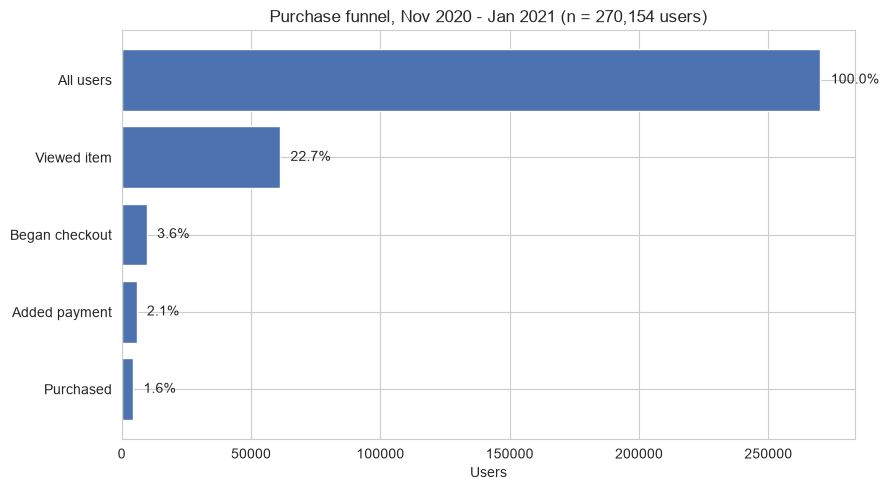

In [18]:
steps = ['All users', 'Viewed item', 'Began checkout', 'Added payment', 'Purchased']
users = [270154, 61252, 9715, 5751, 4419]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(steps, users, color='#4C72B0')
ax.invert_yaxis()

for i in range(len(users)):
    pct = users[i] / users[0] * 100
    ax.text(users[i] + 4000, i, str(round(pct, 1)) + '%', va='center')

ax.set_xlabel('Users')
ax.set_title('Purchase funnel, Nov 2020 - Jan 2021 (n = 270,154 users)')
plt.tight_layout()
plt.savefig('../outputs/funnel_overall.png', dpi=150, bbox_inches='tight')
plt.show()

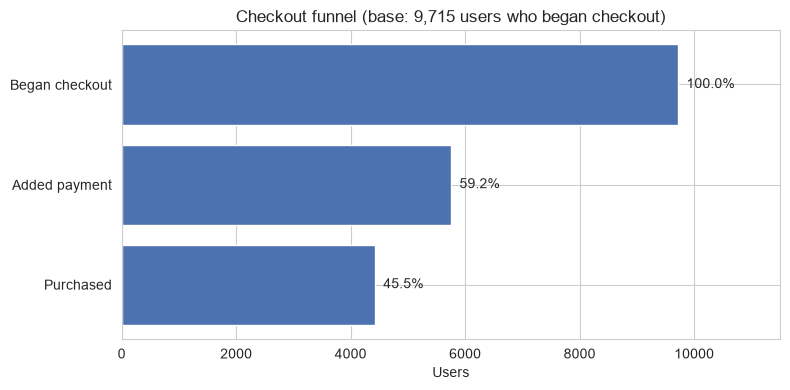

In [19]:
steps = ['Began checkout', 'Added payment', 'Purchased']
users = [9715, 5751, 4419]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(steps, users, color='#4C72B0')
ax.invert_yaxis()

for i in range(len(users)):
    pct = users[i] / users[0] * 100
    ax.text(users[i] + 150, i, str(round(pct, 1)) + '%', va='center')

ax.set_xlim(0, 11500)
ax.set_xlabel('Users')
ax.set_title('Checkout funnel (base: 9,715 users who began checkout)')
plt.tight_layout()
plt.savefig('../outputs/funnel_checkout.png', dpi=150, bbox_inches='tight')
plt.show()

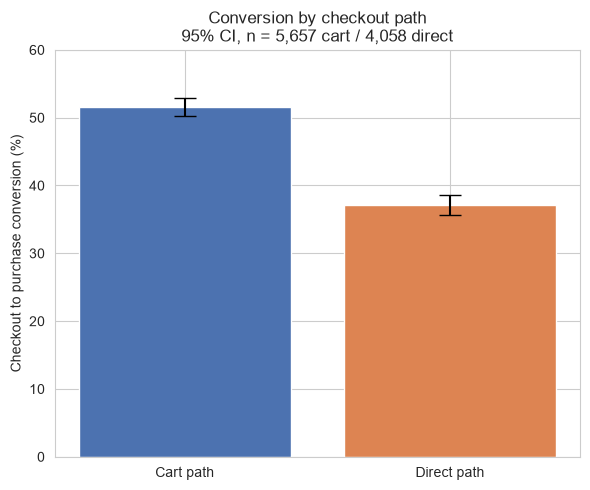

In [13]:
paths = ['Cart path', 'Direct path']
rates = [cart_rate * 100, direct_rate * 100]
lower_errors = [(cart_rate - cart_lower) * 100, (direct_rate - direct_lower) * 100]
upper_errors = [(cart_upper - cart_rate) * 100, (direct_upper - direct_rate) * 100]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(paths, rates, yerr=[lower_errors, upper_errors], capsize=8,
       color=['#4C72B0', '#DD8452'])

ax.set_ylabel('Checkout to purchase conversion (%)')
ax.set_ylim(0, 60)
ax.set_title('Conversion by checkout path\n95% CI, n = 5,657 cart / 4,058 direct')
plt.tight_layout()
plt.savefig('../outputs/path_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

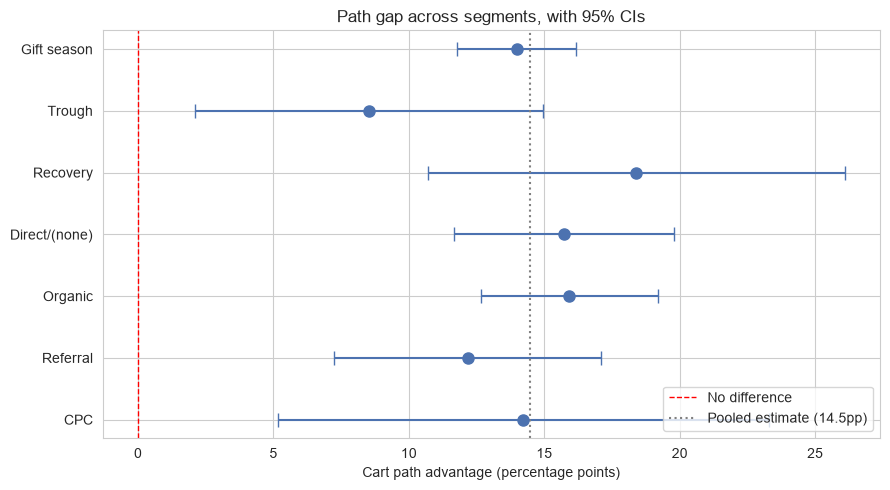

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

y_positions = range(len(results_df))
gaps = results_df['Gap pp']
lower = gaps - results_df['CI low']
upper = results_df['CI high'] - gaps

ax.errorbar(gaps, y_positions, xerr=[lower, upper], fmt='o',
            color='#4C72B0', capsize=5, markersize=8)
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No difference')
ax.axvline(14.47, color='gray', linestyle=':', linewidth=1.5, label='Pooled estimate (14.5pp)')

ax.set_yticks(list(y_positions))
ax.set_yticklabels(results_df['Segment'])
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.set_xlabel('Cart path advantage (percentage points)')
ax.set_title('Path gap across segments, with 95% CIs')
plt.tight_layout()
plt.savefig('../outputs/subgroup_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

**Established:** users reaching checkout via the cart convert 14.47pp better
than those going direct (95% CI [12.49, 16.44], p < 0.001, Cohen's h = 0.292).
The gap holds in all seven subgroups tested across three time periods and four
traffic channels, with effect sizes clustered at 0.24–0.32.

**Not established:** causation. Every test here compares groups that selected
themselves into their condition. The next notebook designs an experiment to
resolve what observational data cannot.